In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from deep_macrofin import PDEModel
from deep_macrofin import Comparator, OptimizerType, set_seeds
from tqdm import tqdm
from torch.func import jacrev, hessian, vmap

In [2]:
c_grid = [0.01, 1.0]

params_baseline = {
    "mu": 0.,
    "siga": 0.,
    "sigx": 0.12,
    "rho": -0.2,
    "carry_cost": 0.02,
    "alpha": 0.18,
    "phi": 1.002,
    "prop": 1.06,
    "liquidation": 100,
    "omega": 0.55,
    "r": 0.03,
    "I": 10,
    "xi": 0.015,
    "eps": 1,
}

params = {
    "mu": 0.01,
    "siga": 0.25,
    "sigx": 0.12,
    "rho": -0.2,
    "carry_cost": 0.02,
    "alpha": 0.18,
    "phi": 1.002,
    "prop": 1.06,
    "liquidation": 100,
    "omega": 0.55,
    "r": 0.03,
    "I": 10,
    "xi": 0.015,
    "eps": 1,
}

In [3]:
def compute_hjb(c, F, F_Jac, F_Hess, r, mu, alpha, carry_cost, siga, sigx, rho):
    first_order = (alpha + c * (r - carry_cost - mu)) * F_Jac.reshape(-1, 1)
    # need to change this for higher dimension
    second_order = (siga**2 * c**2 - 2 * rho * siga * sigx * c + sigx**2) * F_Hess.reshape(-1, 1) 
    value_term = (r - mu) * F
    return first_order + 0.5 * second_order - value_term    

def compute_bc(compute_F, c, p, phi, omega, alpha, r, mu):
    F = compute_F(c)
    first_term = torch.max(F - p * (c + phi), dim=0).values
    second_term = torch.tensor(omega * alpha / (r - mu), dtype=torch.float32, device=first_term.device)
    return torch.maximum(first_term, second_term).reshape(-1,1)

def compute_opt(compute_F, cstar, alpha, r, mu, carry_cost):
    '''
    In this function, we try to find the place F(c*)=(alpha+c(r-carry_cost-mu))/(r-mu)

    and enforce that F'(c*)=1
    '''
    f_cstar = compute_F(cstar)
    f_c_cstar = vmap(jacrev(compute_F))(cstar).reshape(-1, 1)

    m = alpha + cstar * (r - carry_cost - mu)
    l = r - mu
    expected_f_cstar = m / l

    # check the position where F = m/l
    # enforce F(c*)=(alpha+c(r-carry_cost-mu))/(r-mu)
    # and F'(c*)=1
    error1 = torch.mean((f_cstar - expected_f_cstar) ** 2)
    error2 = torch.mean((f_c_cstar - 1.) ** 2)
    return error1 + error2


def get_model(
    model_name,
    c_grid,
    params,
    load_only=False,
    baseline=False,
):
    set_seeds(0)
    model_fn = "model_baseline" if baseline else "model"
    model = PDEModel(model_name, config={"num_epochs": 20000, "optimizer_type": OptimizerType.Adam})
    model.set_state(["c"], {"c": c_grid})
    model.add_params(params)
    model.add_learnable_param("cstar", [[0.3]])
    model.register_functions([compute_hjb, compute_bc, compute_opt])
    model.add_endog("F", config={"batch_jac_hes": True})
    model.add_hjb_equation("compute_hjb(c, F, F_Jac, F_Hess, r, mu, alpha, carry_cost, siga, sigx, rho)")
    model.add_hjb_equation("compute_opt(compute_F, cstar, alpha, r, mu, carry_cost)", loss_reduction="None")
    model.add_endog_condition("F", 
                            "F(zero)", {"zero": torch.zeros(1, 1, dtype=torch.float32, device=model.device)},
                            Comparator.EQ,
                            "compute_bc(compute_F, c_lin, prop, phi, omega, alpha, r, mu)",
                            params | {"c_lin": torch.linspace(c_grid[0], c_grid[1], steps=200, dtype=torch.float32, device=model.device).reshape(-1, 1)}
                            )
    if not load_only:
        model.train_model(f"./models/{model_name}", f"{model_fn}.pt", True)
    model.load_model(torch.load(f"./models/{model_name}/{model_fn}.pt", weights_only=False))
    model.eval_model(True)
    return model

In [4]:
model_name = "decamp_liquidation"
output_dir = f"./models/{model_name}"
model_baseline = get_model(model_name, c_grid, params_baseline, load_only=True, baseline=True)
model = get_model(model_name, c_grid, params, load_only=True, baseline=False)

Model loaded


e:\users_ra_local\wu_yuntao\deep-macrofin\.venv\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


===================================Evaluating===================================
loss :: hjbeq_1: 0.0000,
hjbeq_2: 0.0000,
endogvar_F_cond_1: 0.0001,
total_loss: 0.0001
Model loaded
===================================Evaluating===================================
loss :: hjbeq_1: 0.0000,
hjbeq_2: 0.0000,
endogvar_F_cond_1: 0.0000,
total_loss: 0.0000


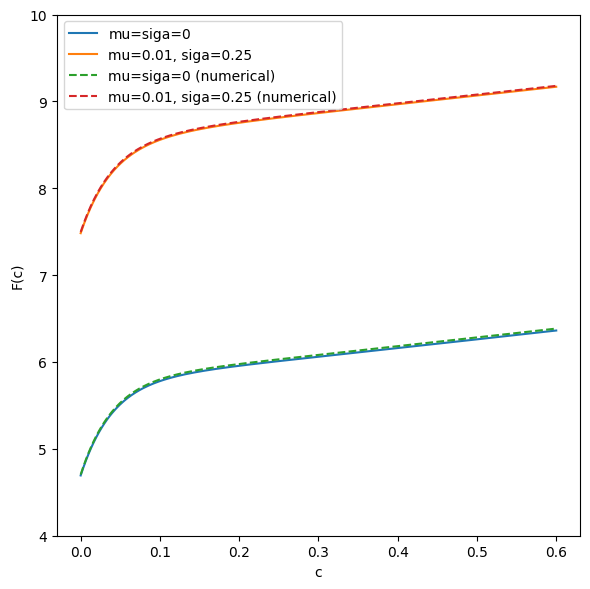

In [5]:
cstar_model_baseline = model_baseline.variable_val_dict["cstar"].item()
cstar_model = model.variable_val_dict["cstar"].item()

numerical = np.load("models/liquidation.npz", allow_pickle=True)
baseline = numerical["baseline"].item()
compare = numerical["compare"].item()

baseline_c_grid_tensor = torch.tensor(baseline["c"], device=model.device, dtype=torch.float32).reshape(-1, 1)
compare_c_grid_tensor = torch.tensor(compare["c"], device=model.device, dtype=torch.float32).reshape(-1, 1)
f_baseline = model_baseline.endog_vars["F"].model(baseline_c_grid_tensor).detach().cpu().numpy().reshape(-1)
f = model.endog_vars["F"].model(compare_c_grid_tensor).detach().cpu().numpy().reshape(-1)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.plot(baseline["c"], f_baseline, label="mu=siga=0")
ax.plot(compare["c"], f, label="mu=0.01, siga=0.25")
ax.plot(baseline["c"], baseline["F"], label="mu=siga=0 (numerical)", linestyle="--")
ax.plot(compare["c"], compare["F"], label="mu=0.01, siga=0.25 (numerical)", linestyle="--")
ax.set_xlabel("c")
ax.set_ylabel("F(c)")
ax.set_ylim(4, 10)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
mse_baseline = np.mean(np.square(f_baseline - baseline["F"]))
mse = np.mean(np.square(f - compare["F"]))
abs_err_cstar_baseline = np.abs(cstar_model_baseline - baseline["cstar"])
abs_err_cstar = np.abs(cstar_model - compare["cstar"])

print(f"MSE mu=0, siga=0: {mse_baseline:.4e}")
print(f"c_star: {cstar_model_baseline:4f}")
print(f"MAE c_star: {abs_err_cstar_baseline:.4f}")

print(f"MSE mu=0.01, siga=0.25: {mse:.4e}")
print(f"c_star: {cstar_model:4f}")
print(f"MAE c_star: {abs_err_cstar:.4f}")

MSE mu=0, siga=0: 4.2580e-04
c_star: 0.357841
MAE c_star: 0.0301
MSE mu=0.01, siga=0.25: 1.2428e-04
c_star: 0.433294
MAE c_star: 0.0112
